<a href="https://colab.research.google.com/github/hamed/tabpfn-probes/blob/main/Two_Gaussians_with_TabPFN.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Two Gaussians and a Question: How Sure Should You Be?

*Most ML stories are about being right. This one is about knowing how right you are. Two overlapping clouds of points, three models, and a small experiment in self-knowledge.*

---

There's a particular kind of mistake that costs more than being wrong: being wrong and not knowing it. We've all met this kind of mistake. We've probably made it more than once. A model that confidently delivers nonsense is worse than one that hesitates — and an honest hesitation is worth more than a lucky guess.

So this little notebook is about something quite simple. When a model gives you a prediction, *should you believe how confident it sounds?* What does it even mean for a model to know how confident it should be?

To get at this, we're going to do something mild. Take two clouds of points — two Gaussians, sitting in one dimension. We'll mix them, hand them to three models, and ask each model two questions:

1. **What is the probability this point came from cloud one?**
2. **How sure are you about that?**

The first is the usual question. The second is the interesting one. They don't always have the same answer — and the gap between them is the whole story.

## A little setup

A Gaussian is just a hill of probability — a cloud that's denser in the middle and thinner at the edges. We have two of these clouds, one with mean $\mu_0$ and width $\sigma_0$, the other with mean $\mu_1$ and width $\sigma_1$. Each point we generate belongs to one or the other, with equal probability.

If we know the parameters, Bayes-optimal classification is straightforward — just compute which cloud is denser at the point in question. Working through the algebra, the Bayes-optimal log-odds are:

$$\log \frac{P(y=1 \mid x)}{P(y=0 \mid x)} = -\frac{1}{2}\left[\frac{(x-\mu_1)^2}{\sigma_1^2} - \frac{(x-\mu_0)^2}{\sigma_0^2}\right] + \log\frac{\sigma_0}{\sigma_1}$$

You can read the structure off this expression. It's quadratic in $x$ — generally. But there's a special case: when the two widths are equal, the quadratic terms cancel, leaving a *linear* function of $x$. That linear form is exactly what logistic regression assumes about the world. So the same equation tells us, in advance, where logistic regression should win cleanly and where it should run into a wall.

Two experiments. First with equal widths, where the math is a sigmoid and everyone's happy. Then with one cloud narrow and one cloud broad, where the math becomes a U-shape and not everyone can keep up.

Each experiment produces three stacked panels: the predicted probability on top, then the predictive entropy on linear scale, then the same entropy on log scale. The first panel tells you *what* the model predicts. The second tells you *how confident* it is, in human-readable terms. The third tells you something the linear scale hides — how confidence behaves at the extremes, where the question gets very easy or very hard.


In [1]:
!pip install tabpfn_client --quiet


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 46.6/46.6 kB 2.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 51.8/51.8 kB 2.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 240.8/240.8 kB 8.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 73.1/73.1 kB 4.4 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-colab 1.0.0 requires requests==2.32.4, but you have requests 2.34.2 which is incompatible.


In [2]:
# Setup, imports, auth.
# Put your TabPFN token in Colab Secrets (key icon, left sidebar) as TABPFN_TOKEN.
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import norm

from tabpfn_client import TabPFNClassifier, set_access_token
from sklearn.linear_model import LogisticRegression

try:
    from google.colab import userdata
    token = userdata.get('TABPFN_TOKEN')
except Exception:
    token = os.environ.get('TABPFN_TOKEN', '')

if not token:
    raise RuntimeError(
        "No TabPFN token found. Add TABPFN_TOKEN to Colab Secrets "
        "(left sidebar -> key icon) or set the env var."
    )
set_access_token(token)


In [7]:
def generate(n, mu0, mu1, sigma0, sigma1, seed=None):
    """Equal-prior two-Gaussian mixture in 1D."""
    rng = np.random.default_rng(seed)
    y = rng.integers(0, 2, size=n)
    x = np.where(
        y == 0,
        rng.normal(mu0, sigma0, size=n),
        rng.normal(mu1, sigma1, size=n),
    )
    return pd.DataFrame({"x": x, "y": y})

def theory_posterior(x, mu0, mu1, sigma0, sigma1):
    """Bayes-optimal P(y=1 | x) for equal-prior two-Gaussian mixture."""
    p_x_given_0 = norm.pdf(x, mu0, sigma0)
    p_x_given_1 = norm.pdf(x, mu1, sigma1)
    return p_x_given_1 / (p_x_given_0 + p_x_given_1)

def binary_entropy(p):
    """Binary entropy in nats, for an array of P(y=1) values."""
    p = np.clip(p, 1e-12, 1 - 1e-12)
    return -(p * np.log(p) + (1 - p) * np.log(1 - p))

def fit_tabpfn(train, test):
    clf = TabPFNClassifier()
    clf.fit(train[['x']], train['y'])
    return clf.predict_proba(test[['x']])[:, 1]

def fit_logistic(train, test):
    clf = LogisticRegression()
    clf.fit(train[['x']], train['y'])
    return clf.predict_proba(test[['x']])[:, 1]

def plot_experiment(df_test, mu0, mu1, sigma0, sigma1, title):
    """Three-panel figure: posterior, entropy (linear), entropy (log)."""
    fig, (ax_p, ax_h, ax_hlog) = plt.subplots(
        3, 1, figsize=(9, 9.5), sharex=True,
        gridspec_kw={'height_ratios': [2, 1.3, 1.3]},
    )

    x = df_test.x.values

    # Faint backdrop: the two Gaussian densities (rescaled for visual).
    p0_pdf = norm.pdf(x, mu0, sigma0)
    p1_pdf = norm.pdf(x, mu1, sigma1)
    pdf_scale = max(p0_pdf.max(), p1_pdf.max())
    ax_p.fill_between(x, 0, p0_pdf / pdf_scale, alpha=0.10, color='tab:blue',   label='class 0 density')
    ax_p.fill_between(x, 0, p1_pdf / pdf_scale, alpha=0.10, color='tab:orange', label='class 1 density')

    # Curves shared across panels.
    series = [
        ('P_theory',       dict(color='k',       lw=2.5,    label='theory (Bayes-optimal)')),
        ('P_logistic',     dict(color='tab:red', lw=2,      label='logistic regression  n=10000')),
        ('P_tabpfn_100',   dict(linestyle='--',  alpha=0.6, label='TabPFN  n=100')),
        ('P_tabpfn_1000',  dict(linestyle='--',  alpha=0.7, label='TabPFN  n=1000')),
        ('P_tabpfn_10000', dict(linestyle='--',  alpha=0.9, label='TabPFN  n=10000')),
    ]
    for col, kwargs in series:
        no_label = {k: v for k, v in kwargs.items() if k != 'label'}
        ent = binary_entropy(df_test[col].values)
        ax_p.plot(x, df_test[col], **kwargs)
        ax_h.plot(x, ent, **no_label)
        ax_hlog.plot(x, ent, **no_label)

    # Top panel: posterior.
    ax_p.axhline(0.5, color='grey', alpha=0.3, lw=0.8)
    ax_p.set_ylabel("P(y=1 | x)")
    ax_p.set_title(title)
    ax_p.set_ylim(-0.02, 1.02)
    ax_p.legend(fontsize=8, loc='upper right')
    ax_p.grid(alpha=0.3)

    # Middle panel: entropy, linear scale.
    ax_h.axhline(np.log(2), color='grey', alpha=0.4, lw=0.8, linestyle=':')
    ax_h.text(x[-1], np.log(2), r'  $\ln 2$ (max)', fontsize=8, color='grey',
              va='center', ha='left')
    ax_h.set_ylabel("entropy (nats)")
    ax_h.set_ylim(-0.02, 0.78)
    ax_h.grid(alpha=0.3)

    # Bottom panel: entropy, log scale.
    ax_hlog.set_yscale('log')
    ax_hlog.set_xlabel("x")
    ax_hlog.set_ylabel("entropy (nats), log")
    #ax_hlog.set_ylim(1e-6, 1.0)
    ax_hlog.grid(alpha=0.3, which='both')

    plt.tight_layout()
    plt.show()


## Experiment 1 — Same width, different centers

The two clouds have the same width, $\sigma_0 = \sigma_1 = 2$, with means at $\pm 2$. The quadratic terms in the log-odds cancel, so the truth is a clean sigmoid — exactly the functional form that logistic regression knows by heart. This is the control case. Nothing dramatic should happen. That's the point.


00:02 Fitting... /

00:02 Fitting... Done!
00:00 Predicting... \

00:01 Predicting... Done!
00:00 Fitting... -

00:00 Fitting... Done!
00:00 Predicting... \

00:01 Predicting... Done!
00:00 Fitting... \

00:00 Fitting... Done!
00:00 Predicting... /

00:02 Predicting... Done!


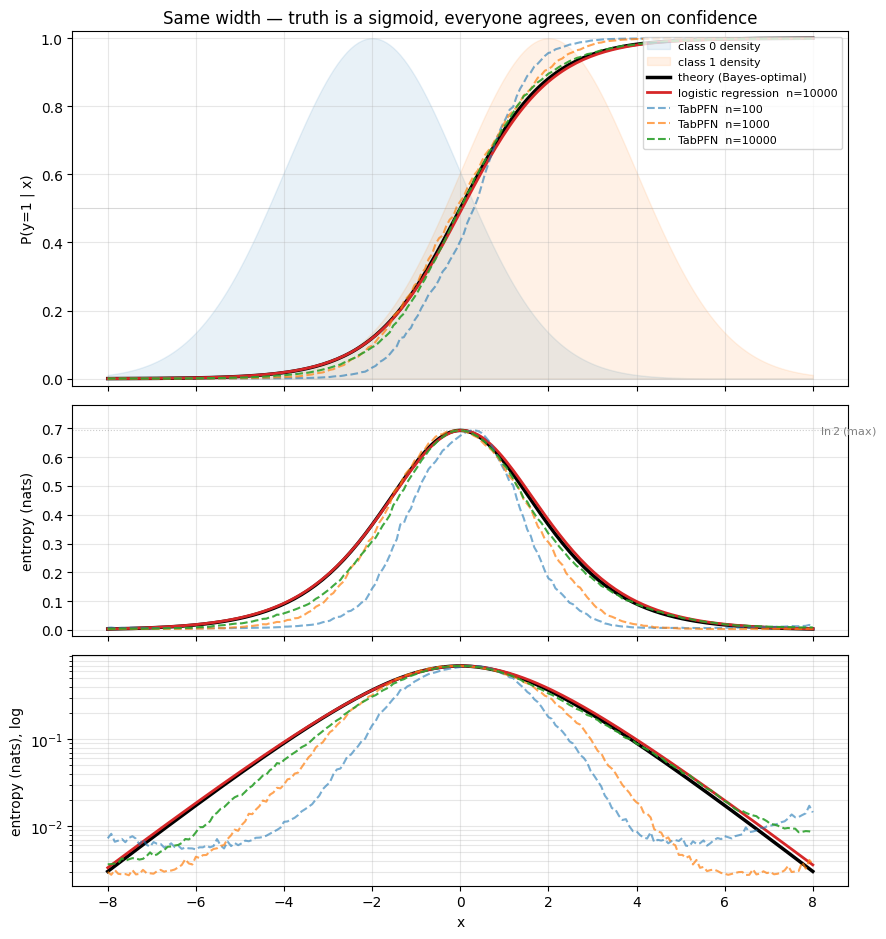

In [8]:
# Experiment 1 parameters
mu0, mu1, sigma0, sigma1 = -2.0, 2.0, 2.0, 2.0

df_train = generate(100_000, mu0, mu1, sigma0, sigma1, seed=0)

df_test = pd.DataFrame({"x": np.linspace(-8, 8, 201)})
df_test['P_theory']        = theory_posterior(df_test.x, mu0, mu1, sigma0, sigma1)
df_test['P_tabpfn_100']    = fit_tabpfn(df_train.sample(100,    random_state=0), df_test)
df_test['P_tabpfn_1000']   = fit_tabpfn(df_train.sample(1000,   random_state=0), df_test)
df_test['P_tabpfn_10000']  = fit_tabpfn(df_train.sample(10000,  random_state=0), df_test)
df_test['P_logistic']      = fit_logistic(df_train.sample(10000, random_state=0), df_test)

plot_experiment(df_test, mu0, mu1, sigma0, sigma1,
                "Same width — truth is a sigmoid, everyone agrees, even on confidence")


**What happened.** Top panel: all four curves overlay each other and the theoretical sigmoid. Same prediction, same shape.

The two entropy panels show the same agreement about *confidence*. The theoretical entropy peaks at $\ln 2 \approx 0.69$ nats right at $x = 0$, where the two clouds overlap completely and the question is genuinely impossible. It drops smoothly to near-zero in the tails, where one cloud has long since taken over and the answer is obvious. Every model — including TabPFN with only 100 training points — tracks this entropy curve almost exactly on linear scale.

On the log scale, you can see how far the curve actually drops — multiple orders of magnitude. The models follow theory most of the way down, with the smaller-sample TabPFN runs flattening a little before theory does. We'll come back to that in the next experiment, where it gets dramatic.

This is what a textbook calibration story looks like. The models aren't just right about *the prediction*. They're right about *how much to trust the prediction*. When the truth has a simple shape that the model's hypothesis class contains, you get this kind of harmony for free.

Now let's break it.


## Experiment 2 — Same center, different widths

Now we share the center and disagree on width. Class 0 is the narrow one ($\sigma_0 = 1$); class 1 is the broad one ($\sigma_1 = 3$). Both clouds are stacked right on top of each other at $x = 0$. Picking out which cloud a point came from is now genuinely hard near the middle — both clouds have lots of density there — and genuinely easy in the tails, where the broad cloud is the only one with any density at all.

The interesting bit: there's no longer any way to tell the clouds apart by saying *the higher numbers are cloud one*. The signal isn't in *where* the point sits; it's in *how typical* the point is. A model that only knows how to draw a single dividing line — and that, precisely, is what logistic regression is — has run out of road.


00:00 Fitting... |

00:00 Fitting... Done!
00:00 Predicting... \

00:01 Predicting... Done!
00:00 Fitting... \

00:00 Fitting... Done!
00:00 Predicting... -

00:01 Predicting... Done!
00:00 Fitting... -

00:00 Fitting... Done!
00:00 Predicting... -

00:01 Predicting... Done!


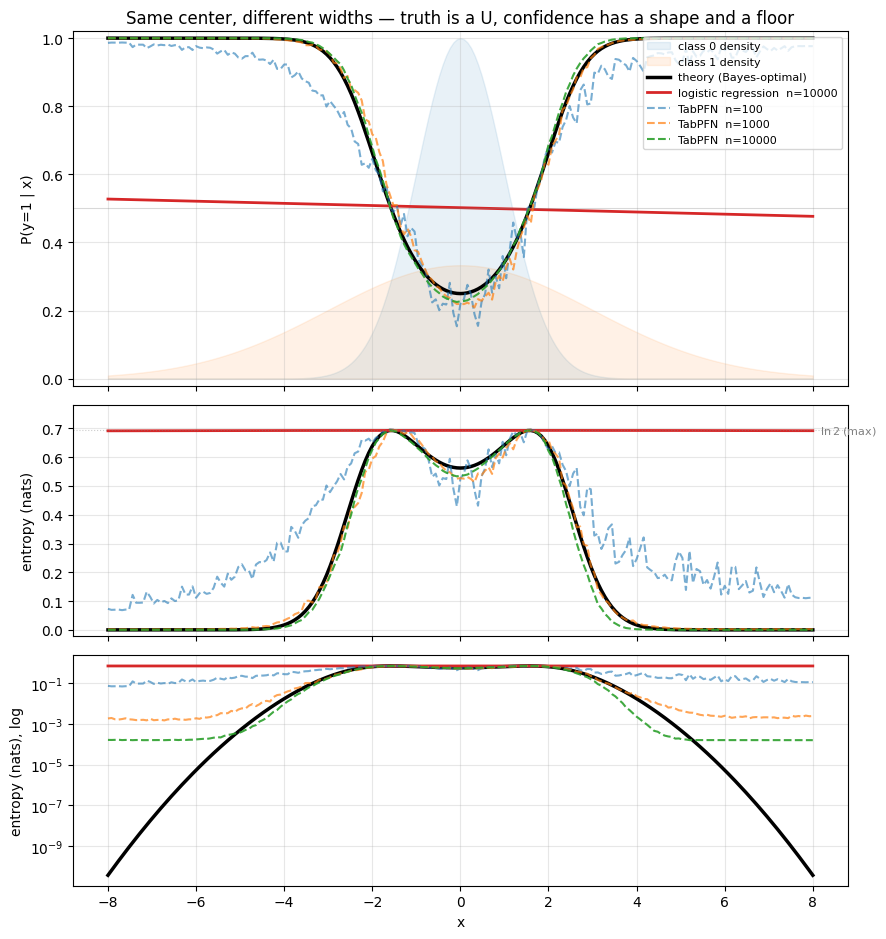

In [9]:
# Experiment 2 parameters
mu0, mu1, sigma0, sigma1 = 0.0, 0.0, 1.0, 3.0

df_train = generate(100_000, mu0, mu1, sigma0, sigma1, seed=1)

df_test = pd.DataFrame({"x": np.linspace(-8, 8, 201)})
df_test['P_theory']        = theory_posterior(df_test.x, mu0, mu1, sigma0, sigma1)
df_test['P_tabpfn_100']    = fit_tabpfn(df_train.sample(100,    random_state=0), df_test)
df_test['P_tabpfn_1000']   = fit_tabpfn(df_train.sample(1000,   random_state=0), df_test)
df_test['P_tabpfn_10000']  = fit_tabpfn(df_train.sample(10000,  random_state=0), df_test)
df_test['P_logistic']      = fit_logistic(df_train.sample(10000, random_state=0), df_test)

plot_experiment(df_test, mu0, mu1, sigma0, sigma1,
                "Same center, different widths — truth is a U, confidence has a shape and a floor")


**What happened — top panel first.** The black theoretical curve is U-shaped: about a 25% chance of being class 1 at the center (the narrow class is denser there), rising to nearly 100% out in the tails (the broad class is the only one home that far out). TabPFN traces this U almost exactly with $n=10000$ training points, and even $n=100$ gets the shape right despite the wobble. Logistic regression is a flat horizontal line at 50%.

Now the two entropy panels. They tell the story from the confidence side, and each panel reveals something the other can't.

**On the linear scale (middle panel),** you see the *shape* of confidence. The theoretical entropy has *two bumps* — low at the center (we are pretty sure, with $P \approx 25\%$, that the point is class 0), rising as we move outward and the two classes start to look equally likely, peaking right where the posterior crosses 50%, then dropping back toward zero in the tails. The theory says: **confidence has a shape**. Sometimes the question is hard. Sometimes it's easy. Where you stand matters.

Logistic regression's entropy is a flat line at the maximum, $\ln 2$. Always. Everywhere. It is uniformly, perfectly, maximally uncertain — not because the world is genuinely uncertain everywhere, but because LR has no instrument with which to be more or less certain depending on $x$. It cannot even register that the question gets *easier* far from the center. In the most precise sense, it is not just wrong about the answer; it is unaware that the question has more than one degree of difficulty.

TabPFN's entropy follows theory closely. It's confident where it should be confident and uncertain where it should be uncertain. Not because it knows it's classifying Gaussians — it doesn't know what a Gaussian is — but because its hypothesis class is broad enough to let the data speak about confidence as well as about predictions.

**And now the log scale (bottom panel) — this is the part I want to talk about most.**

Stretch the y-axis out logarithmically and a new feature becomes visible. The theoretical entropy keeps falling, *and falling*, through multiple orders of magnitude as we move toward the tails. By $|x| = 6$ the theory is at around $10^{-5}$ nats — essentially certain. The model, in principle, should be too.

TabPFN doesn't follow theory all the way down. Look carefully:

- TabPFN with $n=10000$ tracks theory for a couple of orders of magnitude and then *plateaus*, sitting at a floor around $10^{-4}$ nats.
- TabPFN with $n=1000$ plateaus higher, around $10^{-3}$ nats.
- TabPFN with $n=100$ plateaus higher still, around $10^{-1}$ nats.

**The plateau height scales with $1/n$.** That's not noise. That's a *signature*. With less training data, TabPFN refuses to be quite as confident in the tails, even when the math says it should be near-certain. It holds back a little — and the amount it holds back is governed, in this small experiment, by how much data it has seen.

You can read this two ways. As a *bug*: in a problem where you know the truth, TabPFN's residual uncertainty in the tails is just wrong. The theory says the answer is settled; TabPFN insists, faintly, that it isn't quite settled yet. As a *feature*: in a problem where you don't know the truth — which is to say, in almost every real situation a tabular model gets used in — that residual uncertainty is precisely the safety margin you'd want. The model declines to be more certain than its data has earned it the right to be.

This is the same character trait the [companion Fermi-Dirac notebook](https://colab.research.google.com/drive/1BDK77CIQwztPgHfFR4Tz_wzV_-LPcHBz) showed from the other angle: TabPFN's entropy in the tails of a thermodynamic system also refused to fall all the way to zero, plateauing instead. Same model, two different systems, two different reasons the tails should be easy — and the same modest refusal to commit fully to confidence in either case. Honest hesitation as a built-in property.


## So how sure should you be?

There's a useful distinction lurking in these plots, between two kinds of wrongness:

- **Wrong but aware.** The model makes a bad prediction *and* tells you it isn't sure. You see the high entropy, you don't trust the output, you do something else. The mistake costs you nothing.
- **Wrong and confident.** The model makes a bad prediction *and* tells you it's certain. You believe it. You act on it. This is the kind of mistake that ends careers.

Logistic regression in our second experiment is *not exactly* the second kind — it's actually the first kind, in an extreme way. It sits at maximum entropy everywhere, basically telling you it has no idea. That's almost a feature. It is being honest about its uselessness.

The trouble is, it is *uniformly* honest about its uselessness. It cannot tell you that the question is much easier in the tails than at the center. Its lack of confidence isn't tracking anything about the world — it is a single number, repeated, with no relationship to the underlying structure. That isn't really "calibrated uncertainty." It's more like a stopped clock.

TabPFN is right *and* its confidence tracks the truth. It knows the question is hard at $x = 0$ and easy at $x = \pm 5$, and it tells you so. And — the finding that pleased me most in this little experiment — on the log-scale plot we can see something more specific: TabPFN's confidence has not just a *shape* but also a *floor*. It is reluctant, ever so slightly, to extrapolate certainty further than the training data has earned. The floor scales cleanly with sample size: more data, more confidence allowed.

This is the property you want in a model when you don't have the luxury of writing down Nature's equation yourself. Not just good predictions. Not just confidence with a shape. Predictions that come with a *meaningful sense of how much to trust them, including a healthy reluctance to be more certain than the training set has earned.*

Knowing what you don't know is a real thing. It is measurable. It looks like a curve — and on a log scale, you can see that the curve has a floor.
